Đang tải Dataset...
Kích thước X: (129, 100, 6)
Kích thước y: (129,)
-> Tập Train: 103 nhịp
-> Tập Test : 26 nhịp


c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- TÓM TẮT KIẾN TRÚC AI ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 96, 32)         │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 46, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1472)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        94,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,537 (396.63 KB)

 Trainable params: 101,537 (396.63 KB)

 Non-trainable params: 0 (0.00 B)


Bắt đầu cho AI đi học...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.7767 - loss: 3.7409 - val_accuracy: 0.9231 - val_loss: 2.0027
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9223 - loss: 1.5524 - val_accuracy: 0.9615 - val_loss: 1.9071
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8835 - loss: 1.6821 - val_accuracy: 0.9615 - val_loss: 1.3079
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9320 - loss: 1.2057 - val_accuracy: 0.9615 - val_loss: 2.0963
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9320 - loss: 0.9970 - val_accuracy: 0.9231 - val_loss: 1.1677
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8932 - loss: 1.2828 - val_accuracy: 0.9231 - val_loss: 1.0240
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9320 - loss: 0.9397 - val_accuracy: 0.9231 - val_loss: 1.3080
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9223 - loss: 0.7178 - val_accuracy:


💾 Đã lưu não bộ AI thành file 'bicep_curl_1dcnn.h5'


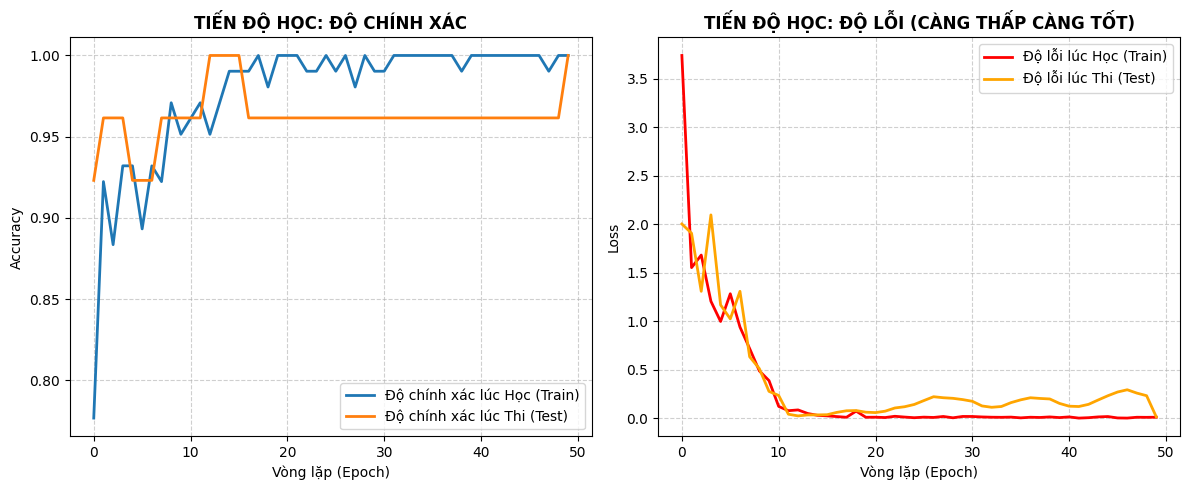


🎯 KẾT QUẢ THI THỬ TRÊN TẬP TEST:
-> Độ chính xác (Accuracy): 100.00%


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# ==========================================
# 1. TẢI VÀ CHUẨN BỊ DỮ LIỆU
# ==========================================
print("Đang tải Dataset...")
X = np.load('X_dataset.npy')
y = np.load('y_dataset.npy')

print(f"Kích thước X: {X.shape}") # Kỳ vọng: (Số nhịp, 100, 6)
print(f"Kích thước y: {y.shape}")

# Chia dữ liệu: 80% để Học (Train), 20% để Thi thử (Test)
# stratify=y đảm bảo tỷ lệ Đúng/Sai ở 2 tập là cân bằng nhau
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"-> Tập Train: {X_train.shape[0]} nhịp")
print(f"-> Tập Test : {X_test.shape[0]} nhịp")

# ==========================================
# 2. XÂY DỰNG KIẾN TRÚC 1D-CNN (DÀNH CHO TINYML)
# ==========================================
model = Sequential()

# Lớp Kính lúp 1: Dùng 32 bộ lọc, kích thước cửa sổ trượt = 5
model.add(Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(100, 6)))
# Lớp Tóm tắt 1: Nén đi một nửa
model.add(MaxPooling1D(pool_size=2))

# Lớp Kính lúp 2: Dùng 64 bộ lọc để nhìn sâu hơn vào chi tiết
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))

# Duỗi phẳng dữ liệu
model.add(Flatten())

# Lớp Não bộ xử lý
model.add(Dense(64, activation='relu'))
# Dropout 50%: Bắt AI nhắm 1 mắt lại khi học để chống học vẹt (Overfitting)
model.add(Dropout(0.5))

# Lớp Quyết định (Output): 1 Node dùng Sigmoid cho bài toán Nhị phân
model.add(Dense(1, activation='sigmoid'))

# Compile mô hình
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

print("\n--- TÓM TẮT KIẾN TRÚC AI ---")
model.summary()

# ==========================================
# 3. HUẤN LUYỆN (TRAINING)
# ==========================================
print("\nBắt đầu cho AI đi học...")
# Epochs = 50: Đọc đi đọc lại quyển sách dữ liệu 50 lần
# Batch_size = 16: Mỗi lần học nhồi 16 nhịp vào đầu
history = model.fit(X_train, y_train, 
                    epochs=50, 
                    batch_size=16, 
                    validation_data=(X_test, y_test),
                    verbose=1)

# Lưu mô hình lại để sau này nhúng vào ESP32
model.save('bicep_curl_1dcnn.h5')
print("\n💾 Đã lưu não bộ AI thành file 'bicep_curl_1dcnn.h5'")

# ==========================================
# 4. VẼ BIỂU ĐỒ ĐÁNH GIÁ (LEARNING CURVE)
# ==========================================
plt.figure(figsize=(12, 5))

# Biểu đồ Độ chính xác (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Độ chính xác lúc Học (Train)', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Độ chính xác lúc Thi (Test)', linewidth=2)
plt.title('TIẾN ĐỘ HỌC: ĐỘ CHÍNH XÁC', fontweight='bold')
plt.ylabel('Accuracy')
plt.xlabel('Vòng lặp (Epoch)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Biểu đồ Độ lỗi (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Độ lỗi lúc Học (Train)', linewidth=2, color='red')
plt.plot(history.history['val_loss'], label='Độ lỗi lúc Thi (Test)', linewidth=2, color='orange')
plt.title('TIẾN ĐỘ HỌC: ĐỘ LỖI (CÀNG THẤP CÀNG TỐT)', fontweight='bold')
plt.ylabel('Loss')
plt.xlabel('Vòng lặp (Epoch)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ==========================================
# 5. CHẤM ĐIỂM CUỐI CÙNG
# ==========================================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯 KẾT QUẢ THI THỬ TRÊN TẬP TEST:")
print(f"-> Độ chính xác (Accuracy): {test_acc * 100:.2f}%")